# 🏍️ MotoGP Lap Time Predictor – Inference Notebook (Burnout 2025 Finalist)

This notebook demonstrates how to **load a trained XGBoost model** and generate lap time predictions on the provided MotoGP **test dataset** as part of the **Burnout 2025 Datathon** hosted by IEEE Computer Society MUJ.

The final model was trained and tuned during a 12-hour national-level competition involving 124 teams. Our team secured a **Top 15 finish**, advancing to the final round presentation.

---

## 🔧 What This Notebook Does

- Loads the **cleaned test dataset**
- Applies the same **preprocessing steps** used during training (label encoding, missing value handling)
- Loads the **Optuna-tuned XGBoost model**
- Runs **inference** to predict `Lap_Time_Seconds`
- Saves predictions to `submission.csv`

---

## 📁 Files Used

- `/motogp-laptime-dataset/test.csv` – test data
- `/motogp-xgb-model/best_xgb_model.joblib` – trained model
- `/motogp-xgb-model/le_<col>.joblib` – saved label encoders for categorical features

---

## 📦 Tech Stack

- `Pandas`, `NumPy` – data handling
- `scikit-learn` – encoding
- `XGBoost` – regression model
- `Optuna` – hyperparameter tuning
- `Joblib` – model + encoder loading

---

✅ This script is the **final stage** of our pipeline and can be used to generate predictions on new test data using the trained model.

In [ ]:
# MotoGP Lap Time EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


sns.set(style="whitegrid")

df = pd.read_csv("data/train.csv")
df.replace([np.inf, -np.inf], np.nan, inplace=True)


In [13]:
print("\nShape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nInfo:")
df.info()
print("\nSummary statistics:")
print(df.describe())


Shape of dataset: (1914056, 45)

Column names: ['Unique ID', 'Rider_ID', 'category_x', 'Circuit_Length_km', 'Laps', 'Grid_Position', 'Avg_Speed_kmh', 'Track_Condition', 'Humidity_%', 'Tire_Compound_Front', 'Tire_Compound_Rear', 'Penalty', 'Championship_Points', 'Championship_Position', 'Session', 'year_x', 'sequence', 'rider', 'team', 'bike', 'position', 'points', 'shortname', 'circuit_name', 'rider_name', 'team_name', 'bike_name', 'Lap_Time_Seconds', 'Corners_per_Lap', 'Tire_Degradation_Factor_per_Lap', 'Pit_Stop_Duration_Seconds', 'Ambient_Temperature_Celsius', 'Track_Temperature_Celsius', 'weather', 'track', 'air', 'ground', 'starts', 'finishes', 'with_points', 'podiums', 'wins', 'min_year', 'max_year', 'years_active']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1914056 entries, 0 to 1914055
Data columns (total 45 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Unique ID                        int64  
 1   Ride


Missing Value Summary:
         Missing Values          %
Penalty          321292  16.785925


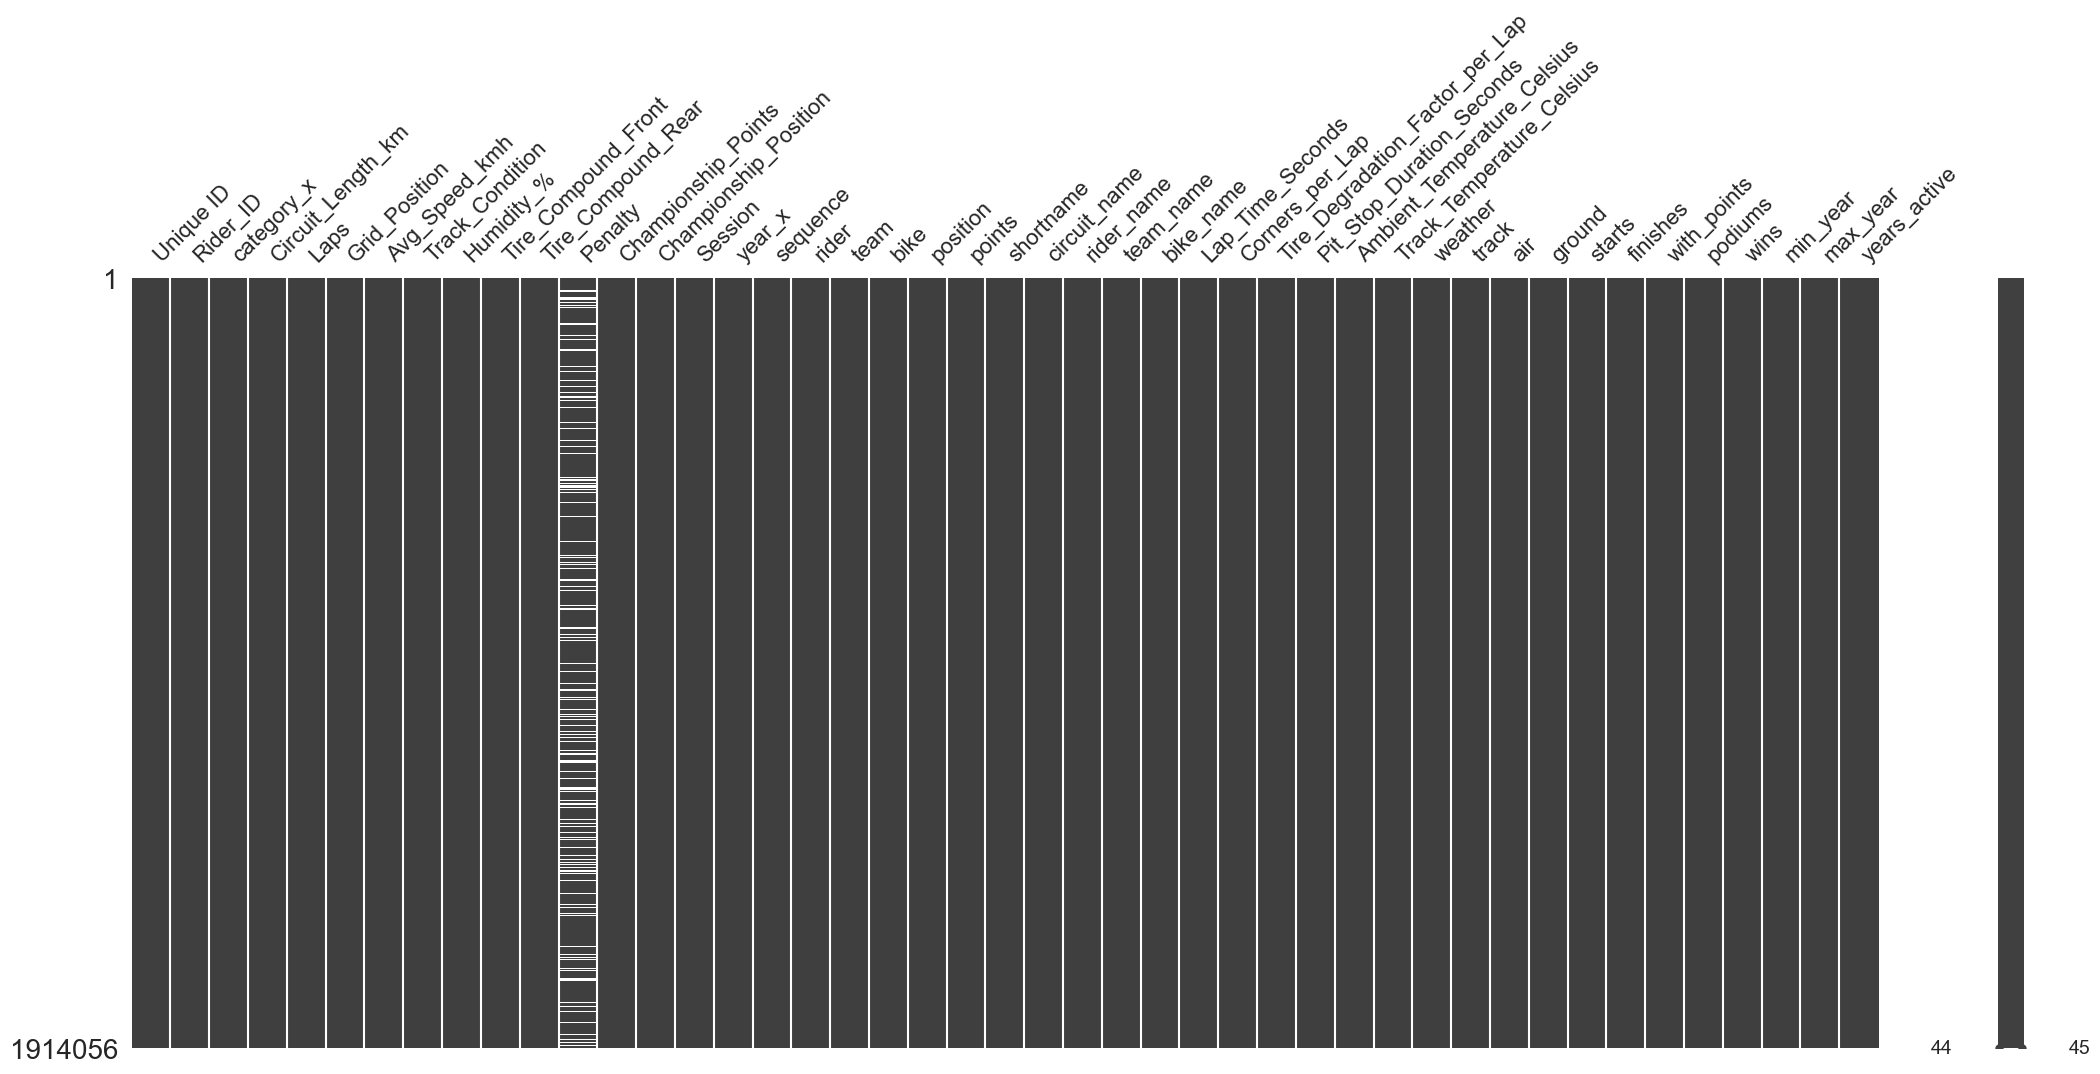

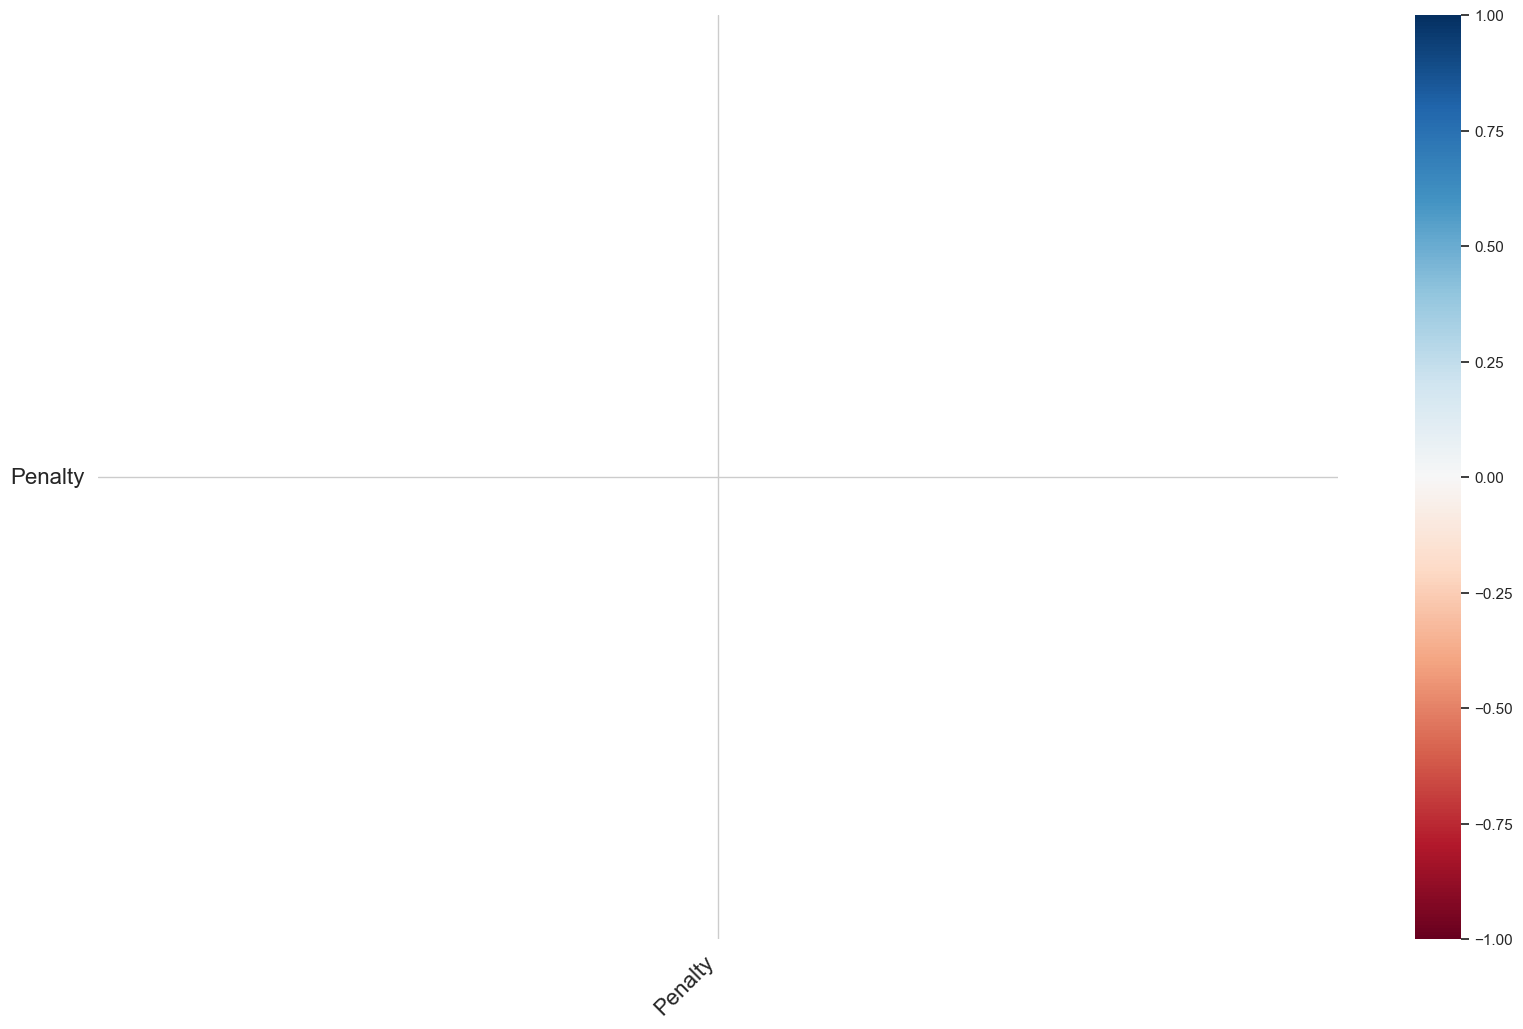

In [14]:
# Missing Value Analysis

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, '%': missing_percent})
print("\nMissing Value Summary:")
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='%', ascending=False))

msno.matrix(df)
plt.show()
msno.heatmap(df)
plt.show()

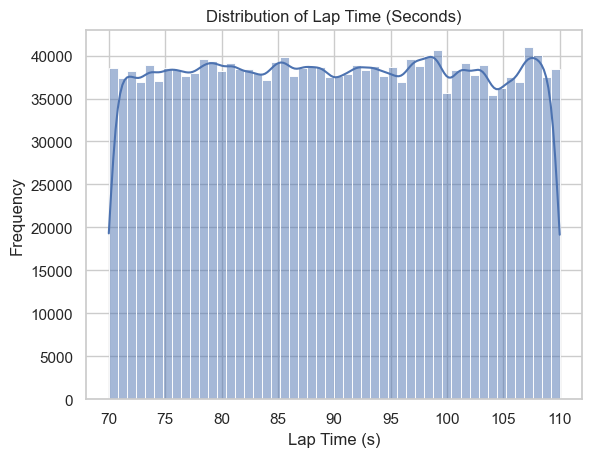

In [15]:
# Target Variable Distribution

sns.histplot(df['Lap_Time_Seconds'], kde=True, bins=50)
plt.title("Distribution of Lap Time (Seconds)")
plt.xlabel("Lap Time (s)")
plt.ylabel("Frequency")
plt.show()

In [16]:
# Categorical Feature Overview 

categorical_cols = [
    'Rider_ID',
    'category_x',
    'Track_Condition',
    'Tire_Compound_Front',
    'Tire_Compound_Rear',
    'Penalty',
    'Session',
    'rider',
    'team',
    'bike',
    'position',
    'shortname',
    'circuit_name',
    'rider_name',
    'team_name',
    'bike_name',
    'weather',
    'track'
]
print("\nSelected Categorical Columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n{col} - Unique Values: {df[col].nunique()}")
    print(df[col].value_counts(normalize=True).head())


Selected Categorical Columns: ['Rider_ID', 'category_x', 'Track_Condition', 'Tire_Compound_Front', 'Tire_Compound_Rear', 'Penalty', 'Session', 'rider', 'team', 'bike', 'position', 'shortname', 'circuit_name', 'rider_name', 'team_name', 'bike_name', 'weather', 'track']

Rider_ID - Unique Values: 8999
Rider_ID
6549    0.000242
9279    0.000241
8397    0.000238
6583    0.000238
4146    0.000237
Name: proportion, dtype: float64

category_x - Unique Values: 3
category_x
Moto2     0.334766
MotoGP    0.334010
Moto3     0.331224
Name: proportion, dtype: float64

Track_Condition - Unique Values: 2
Track_Condition
Wet    0.501319
Dry    0.498681
Name: proportion, dtype: float64

Tire_Compound_Front - Unique Values: 3
Tire_Compound_Front
Medium    0.334020
Soft      0.333348
Hard      0.332632
Name: proportion, dtype: float64

Tire_Compound_Rear - Unique Values: 3
Tire_Compound_Rear
Soft      0.335322
Medium    0.333645
Hard      0.331033
Name: proportion, dtype: float64

Penalty - Unique Values

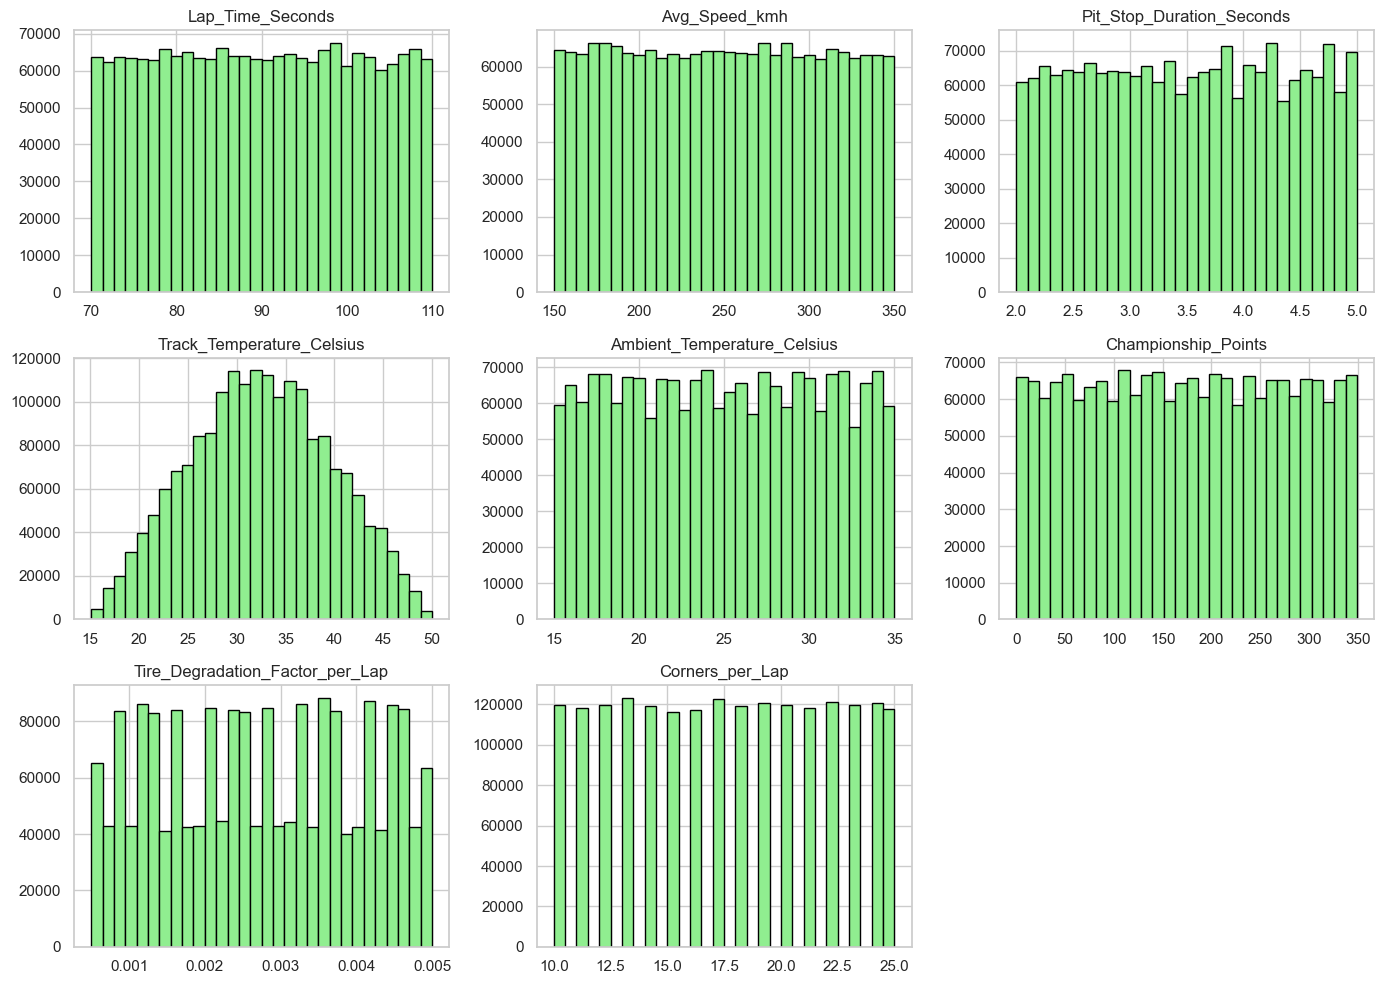

In [18]:
# Numerical Distributions

selected_numerical = [
    'Lap_Time_Seconds',
    'Avg_Speed_kmh',
    'Pit_Stop_Duration_Seconds',
    'Track_Temperature_Celsius',
    'Ambient_Temperature_Celsius',
    'Championship_Points',
    'Tire_Degradation_Factor_per_Lap',
    'Corners_per_Lap'
]

df[selected_numerical].hist(figsize=(14, 10), bins=30, color='lightgreen', edgecolor='black')
plt.tight_layout()
plt.show()

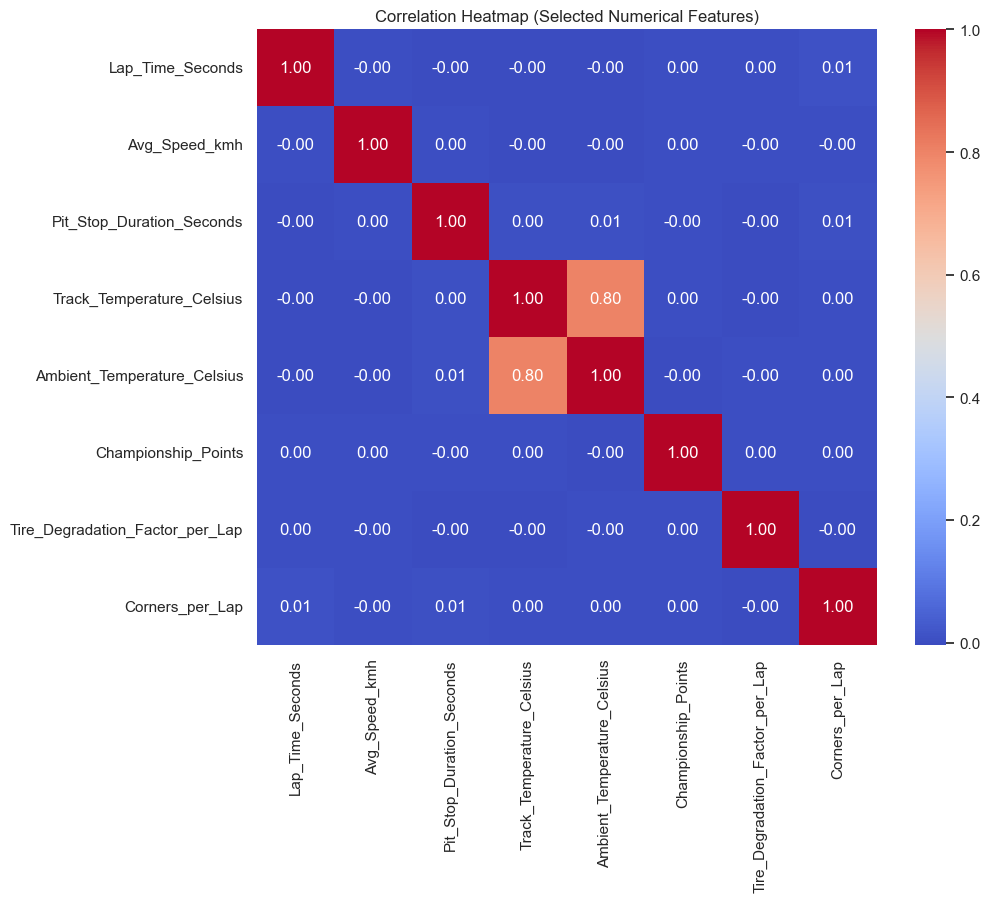

In [19]:
# Correlation Analysis

corr = df[selected_numerical].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Selected Numerical Features)")
plt.show()


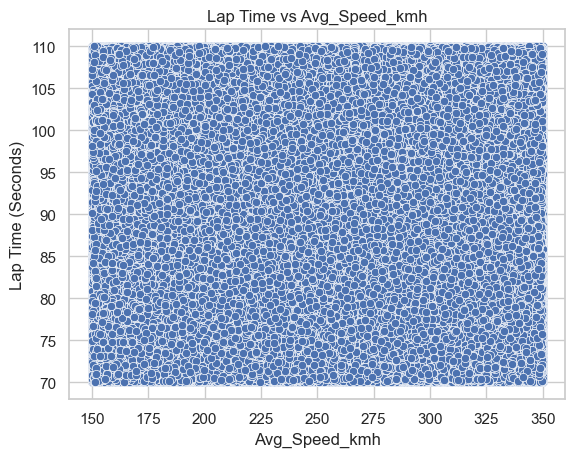

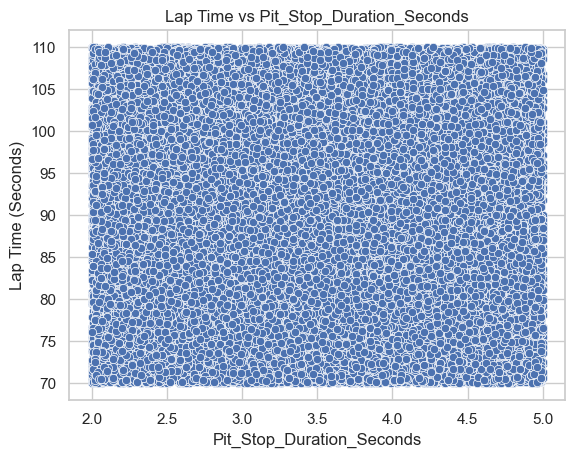

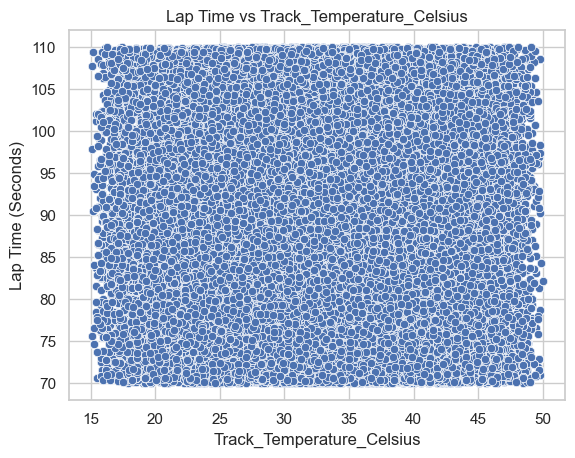

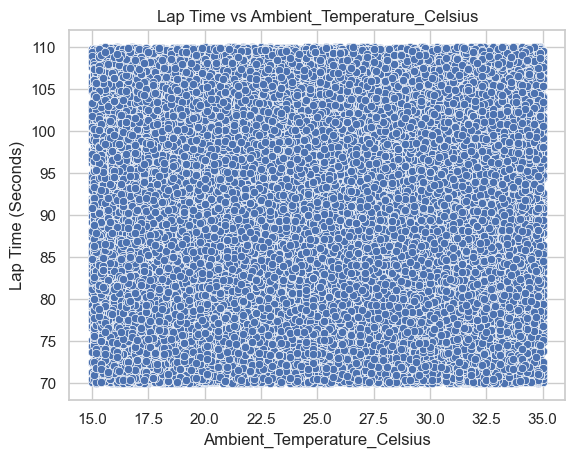

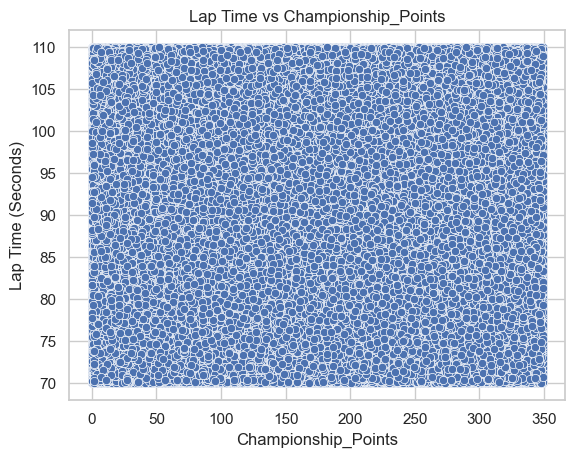

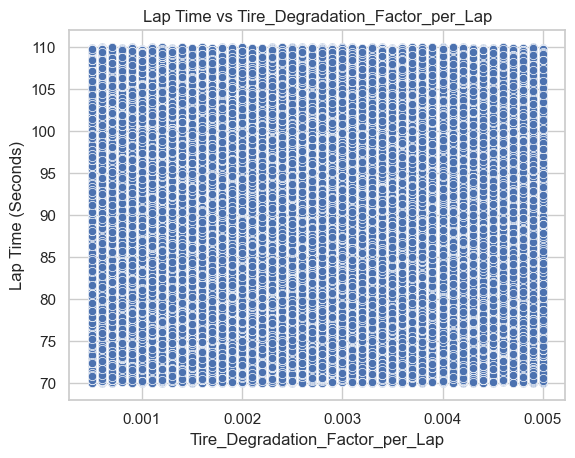

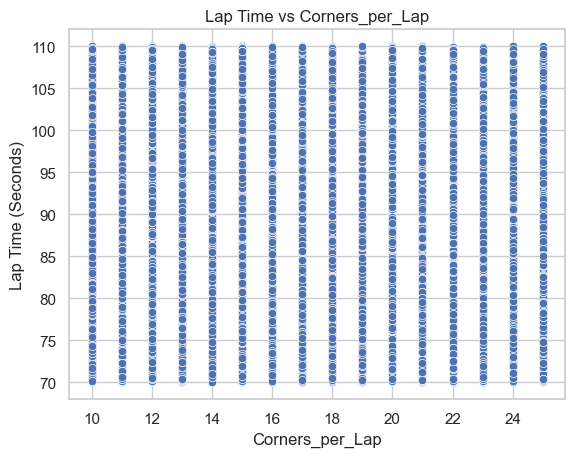

In [20]:
# Target vs Numerical Features

for col in selected_numerical:
    if col != "Lap_Time_Seconds":
        sns.scatterplot(x=df[col], y=df['Lap_Time_Seconds'])
        plt.title(f"Lap Time vs {col}")
        plt.xlabel(col)
        plt.ylabel("Lap Time (Seconds)")
        plt.show()


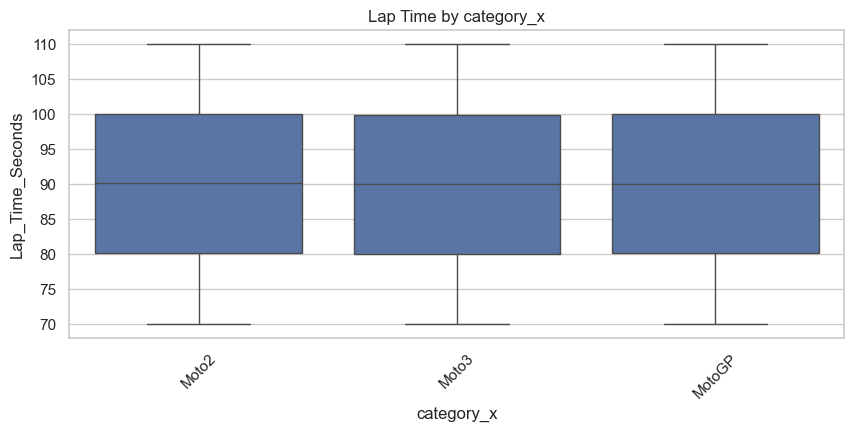

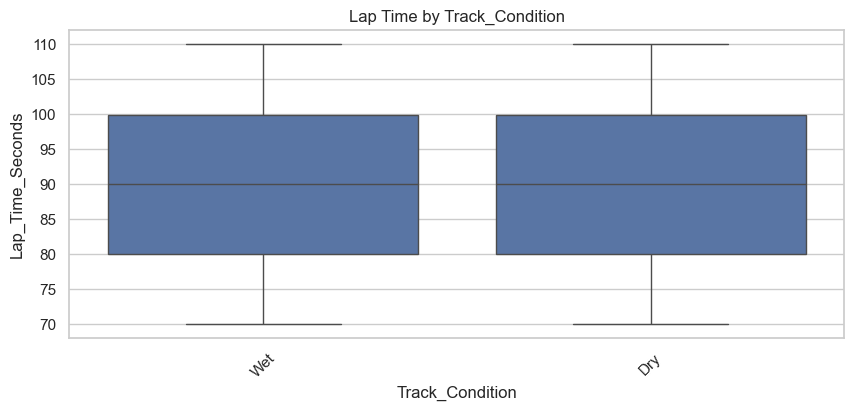

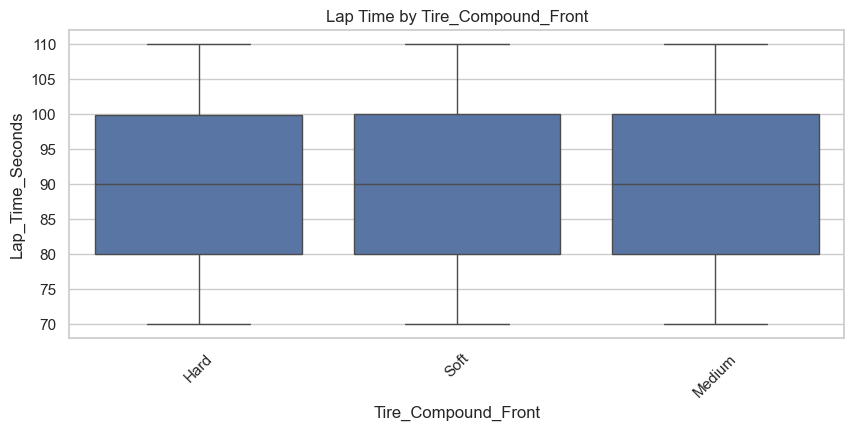

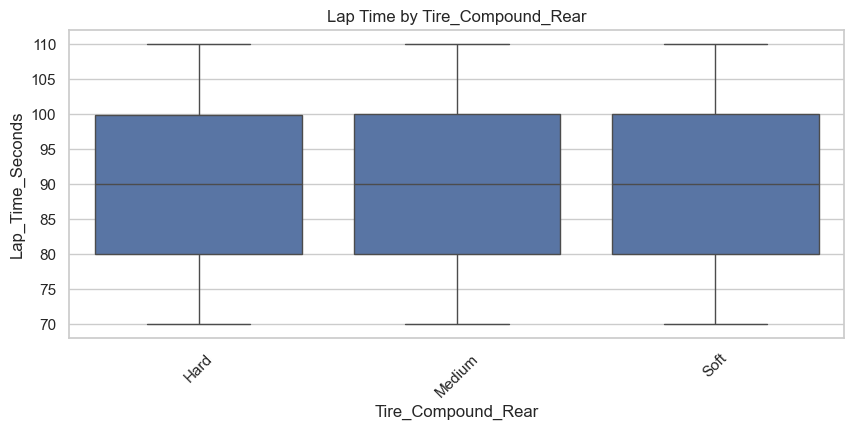

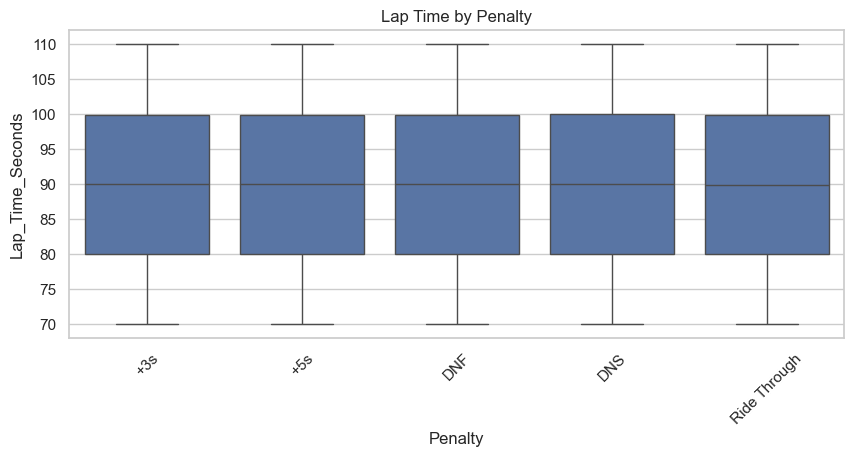

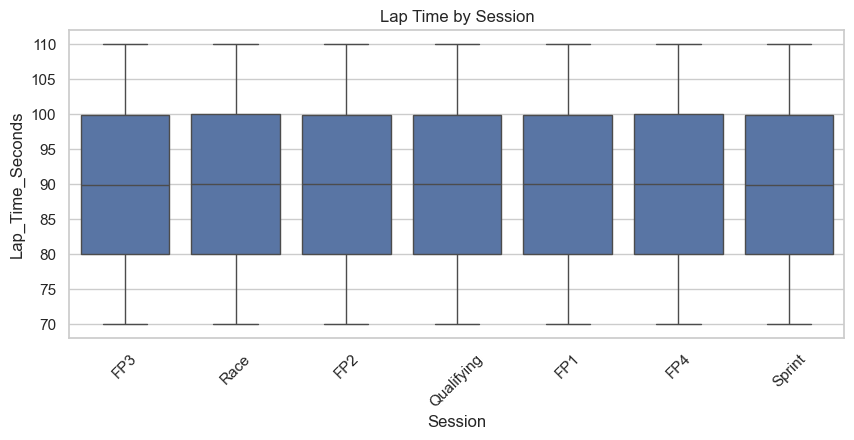

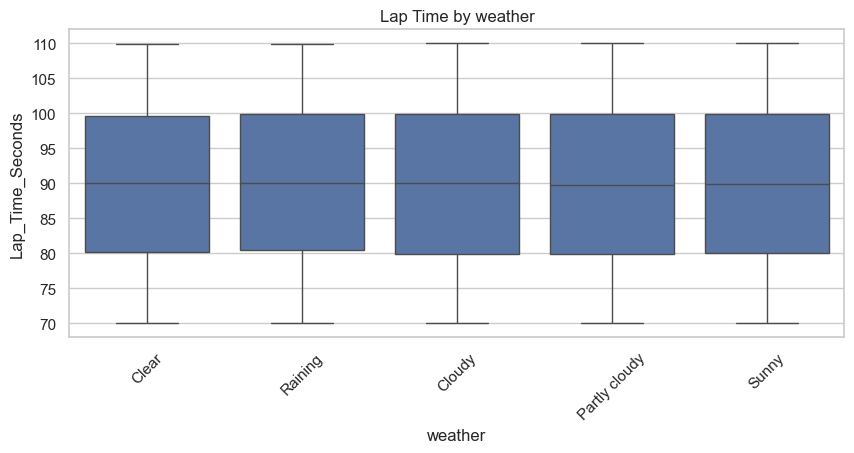

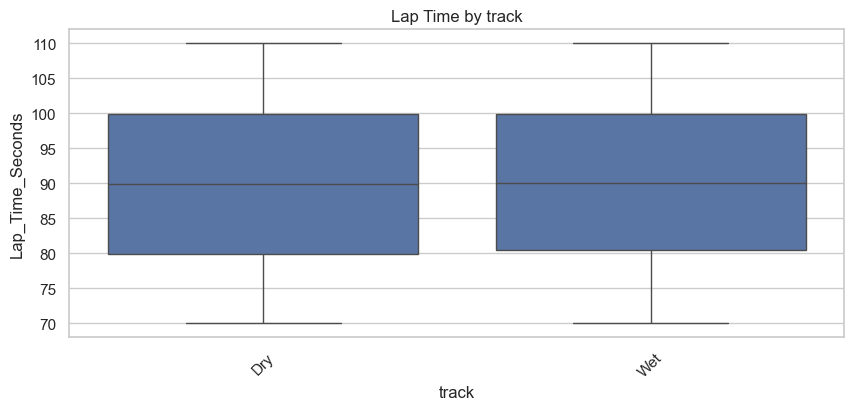

In [21]:

# Target vs Categorical Features

for col in categorical_cols:
    if df[col].nunique() < 20:
        plt.figure(figsize=(10, 4))
        sns.boxplot(x=col, y='Lap_Time_Seconds', data=df)
        plt.title(f"Lap Time by {col}")
        plt.xticks(rotation=45)
        plt.show()


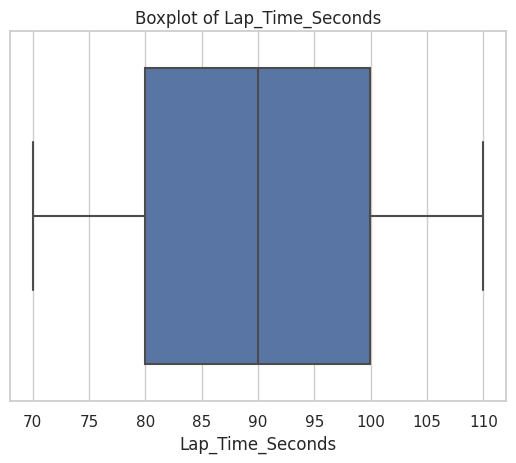

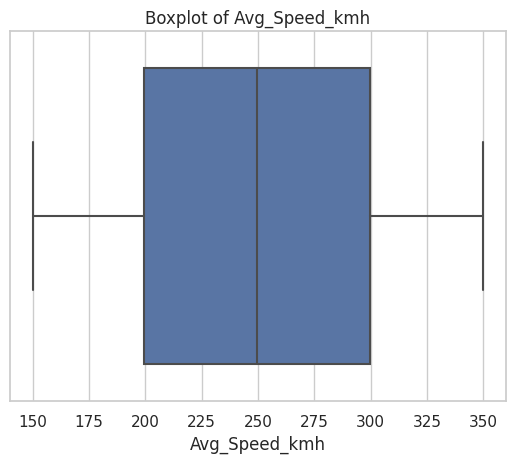

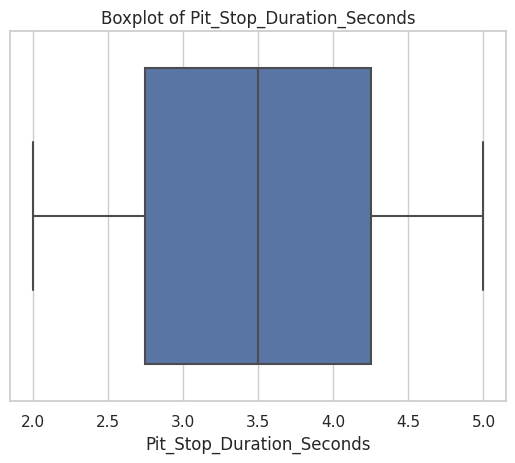

In [ ]:
#  Outlier Detection

outlier_cols = ['Lap_Time_Seconds', 'Avg_Speed_kmh', 'Pit_Stop_Duration_Seconds']

for col in outlier_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

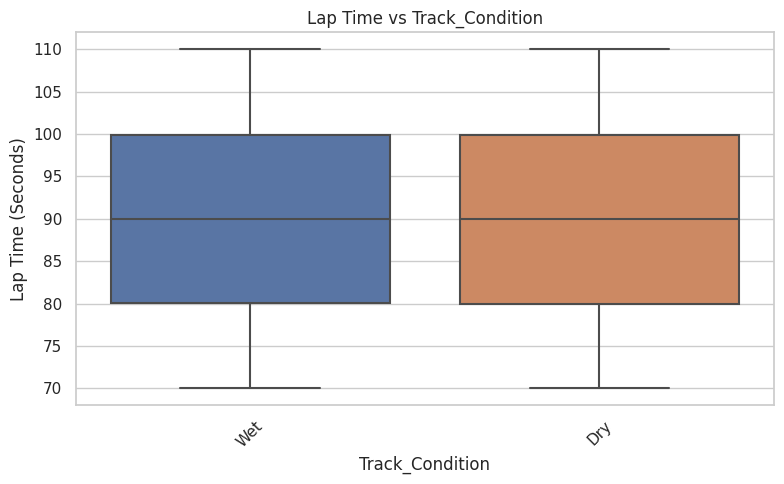

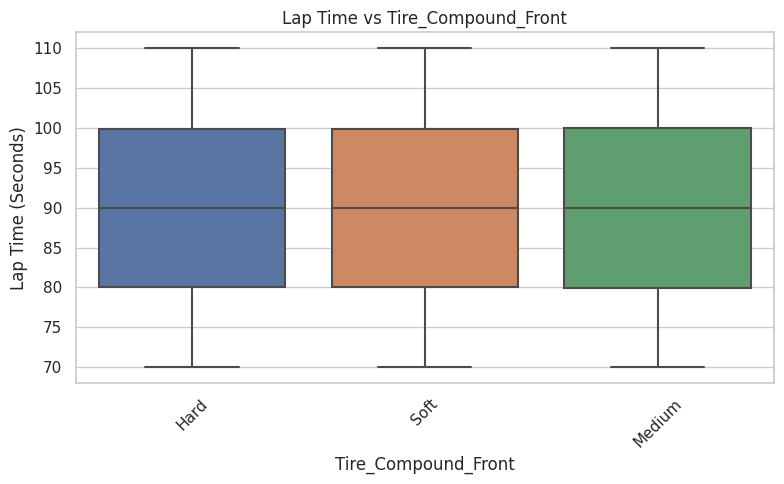

In [ ]:

categorical_cols = ['Track_Condition', 'Tire_Compound_Front']

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=col, y='Lap_Time_Seconds', data=df)
    plt.title(f"Lap Time vs {col}")
    plt.xlabel(col)
    plt.ylabel('Lap Time (Seconds)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# MotoGP Test Prediction

import pandas as pd
import joblib
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load test data
test = pd.read_csv("data/test.csv")

# Load trained XGBoost model
model = joblib.load("models/best_xgb_model.joblib")

# List of columns actually used during training 
train_features = [
    'category_x', 'Circuit_Length_km', 'Laps', 'Grid_Position', 'Avg_Speed_kmh',
    'Track_Condition', 'Humidity_%', 'Tire_Compound_Front', 'Tire_Compound_Rear',
    'Penalty', 'Championship_Points', 'Championship_Position', 'Session', 'year_x',
    'sequence', 'position', 'points', 'Corners_per_Lap', 'Tire_Degradation_Factor_per_Lap',
    'Pit_Stop_Duration_Seconds', 'Ambient_Temperature_Celsius', 'Track_Temperature_Celsius',
    'weather', 'track', 'air', 'ground', 'starts', 'finishes', 'with_points',
    'podiums', 'wins', 'min_year', 'max_year', 'years_active'
]

# Drop extra columns 
test = test[train_features].copy()

# Categorical columns used during training
categorical_cols = [
    'category_x', 'Track_Condition', 'Tire_Compound_Front', 'Tire_Compound_Rear',
    'Penalty', 'Session', 'weather', 'track'
]

# Encode categorical variables
for col in categorical_cols:
    test[col] = test[col].fillna("Unknown").astype(str)
    le = LabelEncoder()
    test[col] = le.fit_transform(test[col])

# Fill remaining missing numerical values 
test = test.fillna(test.mean(numeric_only=True))

# Predict using the model
preds = model.predict(test)

# Create submission file
submission = pd.DataFrame({
    "prediction": preds
})
submission.to_csv("submission.csv", index=False)

print(" submission.csv created successfully!")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [15:26:47] WARNING: /workspace/src/common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


 submission.csv created successfully!
